d:\anaconda3\envs\pytorch\lib\site-packages\anndata\_core\anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
d:\anaconda3\envs\pytorch\lib\site-packages\scanpy\preprocessing\_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Candidates Generated.
Epoch 1/50, Loss: 13.6847
Epoch 2/50, Loss: 5.5082
Epoch 3/50, Loss: 3.7114
Epoch 4/50, Loss: 3.0220
Epoch 5/50, Loss: 2.4018
Epoch 6/50, Loss: 2.1599
Epoch 7/50, Loss: 2.0936
Epoch 8/50, Loss: 1.9489
Epoch 9/50, Loss: 1.8863
Epoch 10/50, Loss: 1.7869
Epoch 11/50, Loss: 1.6527
Epoch 12/50, Loss: 1.5688
Epoch 13/50, Loss: 1.4089
Epoch 14/50, Loss: 1.3781
Epoch 15/50, Loss: 1.3812
Epoch 16/50, Loss: 1.3539
Epoch 17/50, Loss: 1.2838
Epoch 18/50, Loss: 1.2214
Epoch 19/50, Loss: 1.2436
Epoch 20/50, Loss: 1.3689
Epoch 21/50, Loss: 1.0008
Epoch 22/50, Loss: 1.2152
Epoch 23/50, Loss: 1.2147
Epoch 24/50, Loss: 0.9295
Epoch 25/50, Loss: 1.1583
Epoch 26/50, Loss: 1.1644
Epoch 27/50, Loss: 0.9059
Epoch 28/50, Loss: 1.1683
Epoch 29/50, Loss: 0.8703
Epoch 30/50, Loss: 0.8874
Epoch 31/50, Loss: 0.8051
Epoch 32/50, Loss: 0.8486
Epoch 33/50, Loss: 0.9313
Epoch 34/50, Loss: 0.8643
Epoch 35/50, Loss: 0.7752
Epoch 36/50, Loss: 0.8315
Epoch 37/50, Loss: 1.0985
Epoch 38/50, Loss: 0.831

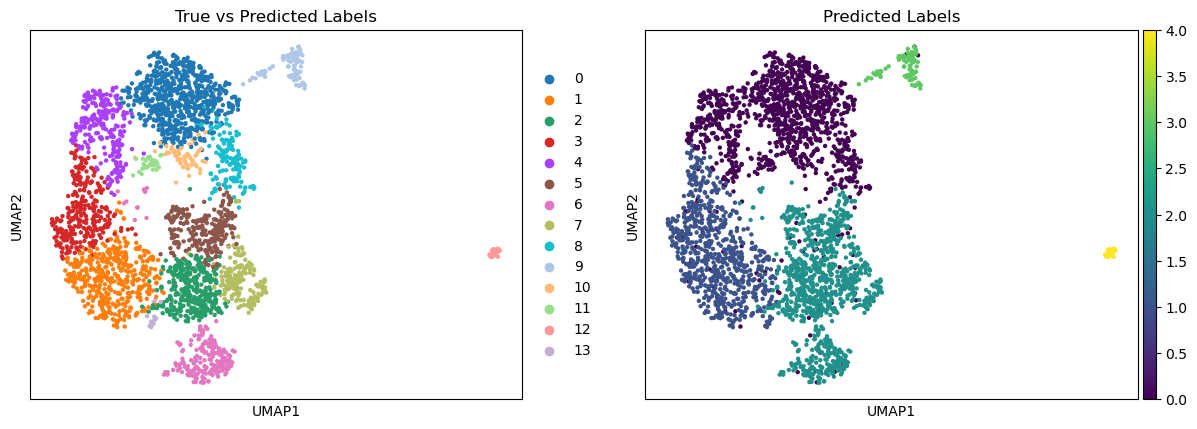

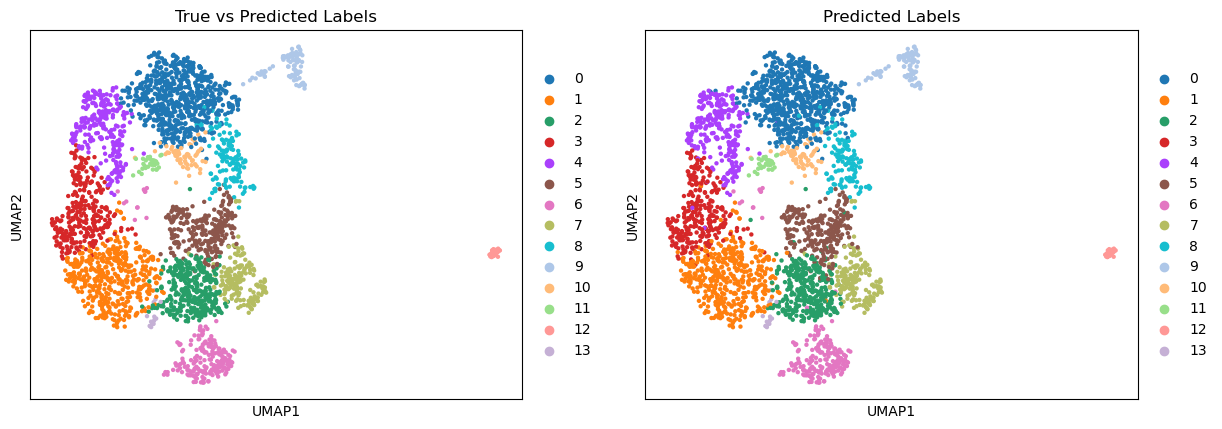

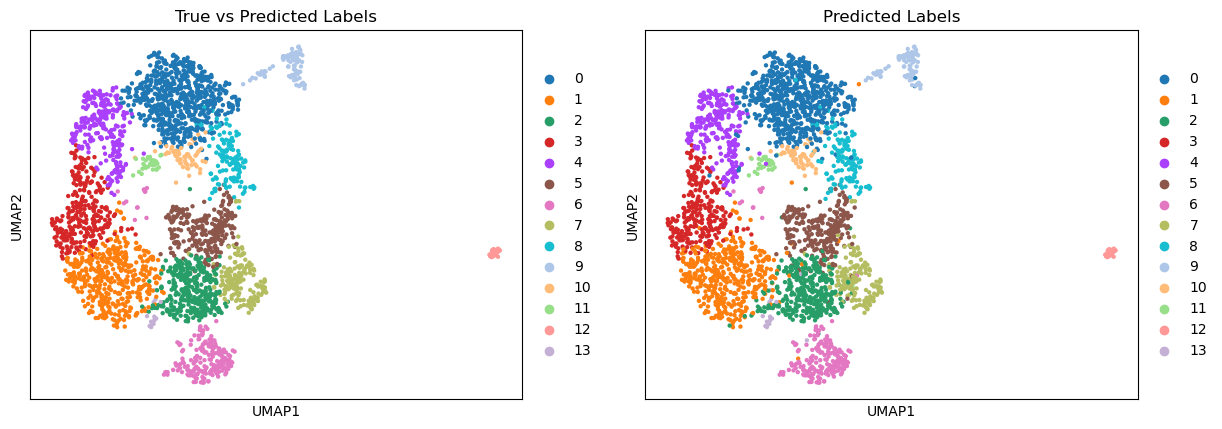

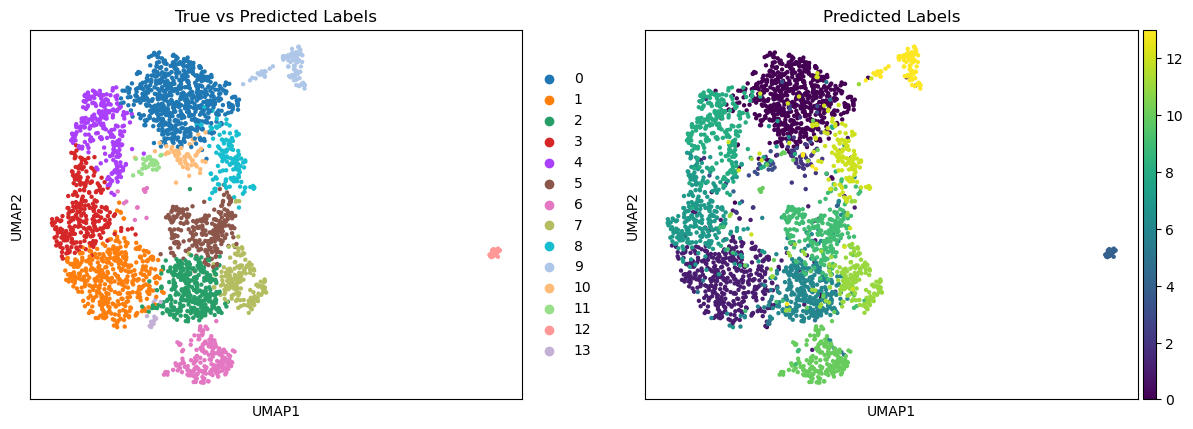

Final ARI Score (LPA): 0.4131
Final ARI Score (SVM): 0.9572
Final ARI Score (Decision Tree): 0.9372
Final ARI Score (Neural Network): 0.7658


In [25]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import adjusted_rand_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
import random
import matplotlib.pyplot as plt
from LPA import label_propagation  # 导入自定义的 LPA 函数
from scipy.sparse import csr_matrix

# 路径设置
data_path = r"D:\Desktop\机器学习\大作业\24机器学习大作业\24机器学习大作业\data\dataset.h5ad"

# VAE 模型定义
class VAE(nn.Module):
    def __init__(self, input_size, output_size, h_dim=400, z_dim=20):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_size, h_dim)
        self.batch_norm1 = nn.BatchNorm1d(h_dim)
        self.fc2 = nn.Linear(h_dim, z_dim)
        self.fc3 = nn.Linear(h_dim, z_dim)
        self.fc4 = nn.Linear(z_dim, h_dim)
        self.batch_norm2 = nn.BatchNorm1d(h_dim)
        self.fc5 = nn.Linear(h_dim, output_size)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = self.batch_norm1(h)
        return self.fc2(h), self.fc3(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(log_var / 2)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc4(z))
        h = self.batch_norm2(h)
        return torch.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_reconst = self.decode(z)
        return x_reconst, mu, log_var

# 数据预处理与候选集生成
def Gen_TrainSet(h5adFile):
    adata = sc.read_h5ad(h5adFile)
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor='seurat', inplace=True)
    sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    candidates = pd.DataFrame(index=adata.obs_names)
    for res in range(1, 10, 2):
        lores = res * 0.1
        sc.tl.leiden(adata, key_added='clusters', resolution=lores)
        tmp_can = pd.DataFrame(
            np.array([adata.obs['clusters'] == x for x in adata.obs['clusters'].unique()]).T,
            index=adata.obs_names)
        candidates = pd.concat([candidates, tmp_can], axis=1)
    return adata, candidates

# 标签遮蔽与错误标签生成
def Gen_maskSet(candidate: pd.DataFrame, errRate=0.20):
    """
    根据候选集生成一维标签数组（适配 LabelPropagation）
    """
    # 初始化标签为 -1（未知）
    labels = np.full(candidate.shape[0], -1, dtype=int)

    # 随机选择一些样本为已知标签
    known_indices = random.sample(range(candidate.shape[0]), int(candidate.shape[0] * (1 - errRate)))

    for idx in known_indices:
        # 找到行中第一个 True 的列索引作为标签
        row = candidate.iloc[idx]
        if row.any():
            labels[idx] = row.idxmax()

    return labels

# 使用 VAE 训练
def train_VAE(candidates, h_dim=400, z_dim=20, num_epochs=50, learning_rate=1e-3, batch_size=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_size = candidates.shape[1]
    model = VAE(input_size=input_size, output_size=input_size, h_dim=h_dim, z_dim=z_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    candidates_np = candidates.to_numpy(dtype=np.float32)
    dataset_size = candidates_np.shape[0]

    for epoch in range(num_epochs):
        # 按批次处理数据
        for start in range(0, dataset_size, batch_size):
            end = min(start + batch_size, dataset_size)
            batch_candidates = candidates_np[start:end]

            # 修复遮蔽矩阵维度
            mask_candidates = np.zeros_like(batch_candidates, dtype=np.float32)
            known_indices = random.sample(range(batch_candidates.shape[0]), int(batch_candidates.shape[0] * 0.95))
            mask_candidates[known_indices] = batch_candidates[known_indices]

            # 转换为张量
            mask_x = torch.tensor(mask_candidates, dtype=torch.float32).to(device)
            origin_x = torch.tensor(batch_candidates, dtype=torch.float32).to(device)

            # 前向传播
            reconst_x, mu, log_var = model(mask_x)
            reconst_loss = F.binary_cross_entropy(reconst_x, origin_x, reduction='mean')
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = reconst_loss + kl_div

            # 反向传播与优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

    return model

# 使用决策树进行训练和预测
def train_decision_tree(X, y, errRate=0.20):
    """
    使用决策树进行训练和预测
    :param X: 特征矩阵
    :param y: 标签数组（包含部分未标记样本）
    :param errRate: 错误率，影响已标记样本数量
    :return: 预测标签数组
    """
    # 仅使用有标签的样本进行训练
    labeled_indices = y != -1
    X_train = X[labeled_indices]
    y_train = y[labeled_indices]

    if len(np.unique(y_train)) < 2:
        raise ValueError("At least two classes are required for Decision Tree training.")

    # 初始化决策树分类器并训练
    clf = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf.fit(X_train, y_train)

    # 对所有样本进行预测
    y_pred = clf.predict(X)
    return y_pred

# 使用 SVM 进行训练和预测
def train_svm(X, y, errRate=0.20):
    """
    使用 SVM 进行训练和预测
    :param X: 特征矩阵
    :param y: 标签数组（包含部分未标记样本）
    :param errRate: 错误率，影响已标记样本数量
    :return: 预测标签数组
    """
    # 仅使用有标签的样本进行训练
    labeled_indices = y != -1
    X_train = X[labeled_indices]
    y_train = y[labeled_indices]

    if len(np.unique(y_train)) < 2:
        raise ValueError("At least two classes are required for SVM training.")

    # 初始化 SVM 模型并训练
    clf = SVC(kernel='linear', C=1.0)  # 使用线性核
    clf.fit(X_train, y_train)

    # 对所有样本进行预测
    y_pred = clf.predict(X)
    return y_pred

# 使用 Neural Network 进行训练和预测
# 手动实现的神经网络
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.lr = lr
        self.hidden_size = hidden_size

        # 初始化权重
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros(output_size)

    def relu(self, x):
        return np.maximum(0, x)

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum(axis=1, keepdims=True)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]

        # 计算梯度
        dZ2 = self.A2 - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0) / m  # Ensure proper shape for db2

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)  # ReLU的梯度
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0) / m  # Ensure proper shape for db1

        # 更新权重
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y, epochs=1000):
        # Convert y to a proper one-hot encoded format
        le = LabelEncoder()
        y = le.fit_transform(y)
        y = np.eye(len(np.unique(y)))[y]  # Convert to one-hot encoding

        for _ in range(epochs):
            self.forward(X)
            self.backward(X, y)

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

def train_neural_network(X, y, num_epochs=50, learning_rate=0.0005, hidden_size=256):
    # 仅使用有标签的样本进行训练
    labeled_indices = y != -1
    X_train = X[labeled_indices]
    y_train = y[labeled_indices]

    # 使用 LabelEncoder 将字符串标签转换为整数标签
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)  # 将标签转换为整数形式

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    input_size = X_train.shape[1]
    output_size = len(np.unique(y_train))  # 类别数目
    model = SimpleNN(input_size, hidden_size, output_size).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)

    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

    X_all = torch.tensor(X, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model(X_all), dim=1).cpu().numpy()

    # 将整数标签转换回原始字符串标签
    y_pred = le.inverse_transform(y_pred)

    return y_pred

# 标签传播训练 (使用自定义的 label_propagation)
def train_LPA(candidate, adata, errRate=0.05):
    """
    使用自定义的标签传播算法训练并预测标签
    """
    X = adata.obsm['X_pca']  # 特征矩阵
    y = Gen_maskSet(candidate, errRate)  # 生成一维标签

    # 获取有标签的类别数
    n_classes = len(np.unique(y[y != -1]))
    if n_classes == 0:
        raise ValueError("No labeled data available.")

    # 将标签转换为 one-hot 编码，未标记的样本保持为全0
    y_one_hot = np.zeros((len(y), n_classes), dtype=np.float32)
    labeled_indices = y != -1
    y_one_hot[labeled_indices, y[labeled_indices]] = 1.0

    # 使用 adata 的邻接矩阵作为 W
    W = adata.obsp['connectivities'].copy()

    y_pred = label_propagation(W, y_one_hot)  # 使用自定义 LPA

    return y_pred

# 计算 ARI
def calculate_ARI(true_labels, predicted_labels):
    ari_score = adjusted_rand_score(true_labels, predicted_labels)
    print(f"ARI Score: {ari_score:.4f}")
    return ari_score

# 可视化结果
def visualize_result(adata, true_labels, predicted_labels):
    adata.obs["True Labels"] = true_labels
    adata.obs["Predicted Labels"] = predicted_labels
    sc.pl.umap(adata, color=["True Labels", "Predicted Labels"], title="True vs Predicted Labels")

# 主函数
if __name__ == "__main__":
    adata, candidates = Gen_TrainSet(data_path)
    print("Candidates Generated.")

    # 使用 VAE 模型进行训练
    vae_model = train_VAE(candidates)
    print("VAE Training Complete.")

    # 使用 LPA 进行训练
    y_pred_LPA = train_LPA(candidates, adata)
    print("Label Propagation Training Complete.")

    # 使用 SVM 进行训练
    y_pred_SVM = train_svm(adata.obsm['X_pca'], adata.obs['clusters'])
    print("SVM Training Complete.")

    # 使用 Decision Tree 进行训练
    y_pred_DT = train_decision_tree(adata.obsm['X_pca'], adata.obs['clusters'])
    print("Decision Tree Training Complete.")

    # 使用 Neural Network 进行训练（手动实现）
    nn_model = SimpleNN(input_size=adata.obsm['X_pca'].shape[1], hidden_size=256, output_size=len(np.unique(adata.obs['clusters'])))
    nn_model.fit(adata.obsm['X_pca'], adata.obs['clusters'], epochs=1000)
    y_pred_NN = nn_model.predict(adata.obsm['X_pca'])
    print("Neural Network Training Complete.")

    # 计算并输出每种方法的 ARI 分数
    true_labels = adata.obs["clusters"]

    ari_LPA = calculate_ARI(true_labels, y_pred_LPA)
    ari_SVM = calculate_ARI(true_labels, y_pred_SVM)
    ari_DT = calculate_ARI(true_labels, y_pred_DT)
    ari_NN = calculate_ARI(true_labels, y_pred_NN)

    # 可视化的结果
    visualize_result(adata, true_labels, y_pred_LPA)
    visualize_result(adata, true_labels, y_pred_SVM)    
    visualize_result(adata, true_labels, y_pred_DT)   
    visualize_result(adata, true_labels, y_pred_NN) 
    
    print(f"Final ARI Score (LPA): {ari_LPA:.4f}")
    print(f"Final ARI Score (SVM): {ari_SVM:.4f}")
    print(f"Final ARI Score (Decision Tree): {ari_DT:.4f}")
    print(f"Final ARI Score (Neural Network): {ari_NN:.4f}")
